# Notebook settimana 1 
### Ripasso di probabilità. Modellare distribuzione di dati con processi noti e distribuzione congiunta.

Questo notebook contiene due diversi tasks da svolgersi leggendo fail  **in formato CSV**:

1. **Stima e predizione** da `game_server_data.csv`.
2. **Probabilità congiunta** per due vriabili aleatorie discrete descritte in `cafe_joint_data.csv`.

---

# Part 1 — Modello stocastico di un processo di conteggio

## Scenario
Osserviamo il numero di richieste di login che arrivano a un server di gaming *al minuto*. Queste sono contenute in un file .csv dove, potenzialmente, potrebbero esserci valori mancanti corrispondenti a problemi di registrazione dei dati.

Sia **X** = numero di richieste di login in un minuto.


In [1]:
# 1.1 Imports
# TO DO: Importate le librerie necessarie per la simulazione, l'analisi e la visualizzazione dei dati

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng()

In [2]:
# 1.2 Load CSV data
csv_path = 'game_server_data.csv'
df = pd.read_csv(csv_path) 

# Show the first few rows of the DataFrame
print('Loaded:', csv_path)
print('Shape:', df.shape)
df.head()


Loaded: game_server_data.csv
Shape: (180, 2)


,minute,requests
0,0.0,1.0
1,NaN,NaN
2,2.0,3.0
3,3.0,3.0
4,4.0,3.0


In [3]:
# 1.3 Basic checks: number of missing values, summary statistics?
print(df.dtypes)
print('\nMissing values:\n', df.isna().sum())
print('\nRequests summary:\n', df['requests'].describe())


minute      float64
requests    float64
dtype: object

Missing values:
 minute      2
requests    4
dtype: int64

Requests summary:
 count    176.000000
mean       2.397727
std        1.625087
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: requests, dtype: float64


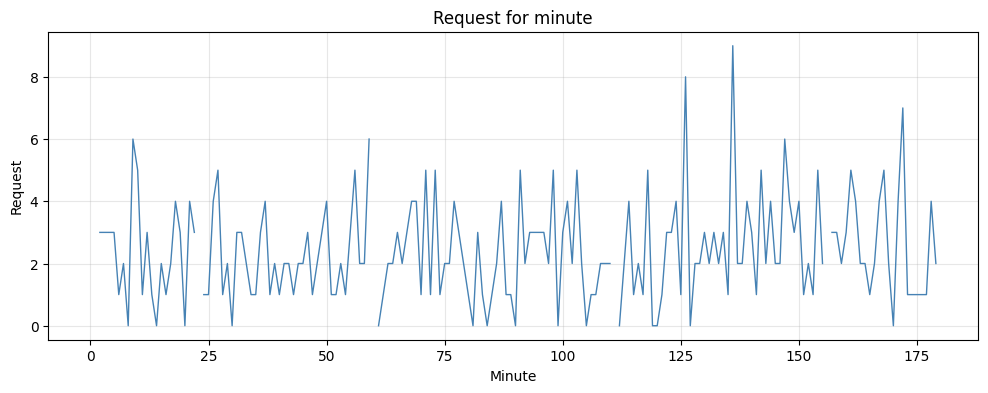

In [4]:
# 1.4 Plot requests per minute to visually inspect the data 
plt.figure(figsize=(12,4))

# TO DO: scrivi il codice per plottare la serie temporale delle richieste al server
plt.plot(df['minute'], df['requests'], color='steelblue', linewidth=1) 
plt.title('Request for minute')                                                     # Titolo del grafico
plt.xlabel('Minute')                                                                # Etichetta asse x
plt.ylabel('Request')                                                               # Etichetta asse y
plt.grid(True, alpha=0.3)                                                           # Griglia del grafico, alpha serve per la trasparenza
plt.show()

In [ ]:
# Drop rows where 'requests' is NaN
clean = df.dropna(subset=['requests']).copy() 

# TO DO - Compute empirical mean and variance of 'requests'
emp_mean = clean['requests'].mean()
emp_var = clean['requests'].var()

lam_hat  = emp_mean

print(f'Empirical mean:     {emp_mean:.4f}')
print(f'Empirical variance: {emp_var:.4f}')
print(f'Variance/Mean:      {emp_var/emp_mean:.4f}')
print(f'Lambda-hat:         {lam_hat:.4f} requests/min')


Empirical mean:     2.3977
Empirical variance: 2.6409
Variance/Mean:      1.1014
Lambda-hat:         2.3977 requests/min


## Commento su Lambda_hat

Dai dati otteniamo:
- media ≈ 2.40
- varianza ≈ 2.64

Il rapporto tra i due valori è di ≈ 1.10 - vicino a 1, il che mi fa pensare ad un processo di Poisson e per un processo di Poisson io so che E[x] = Var[X] = λ.


## Domanda
Qual è un processo stocastico che, sulla base delle quantità empiriche calcolate potrebbe descrivere questo fenomeno? Spiega perché e come questo insieme di dati rappresenta le assunzioni di base giustificando la scelta fatta.

## Risposta

Il processo stocastico adatto è il processo di Poisson perchè:
- Le richieste sono eventi discreti non negativi
- Il rapporto Variance/Mean è molto vicino a 1 
- Gli eventi sembrano indipendenti tra loro
- Il processo sembra stazionario 

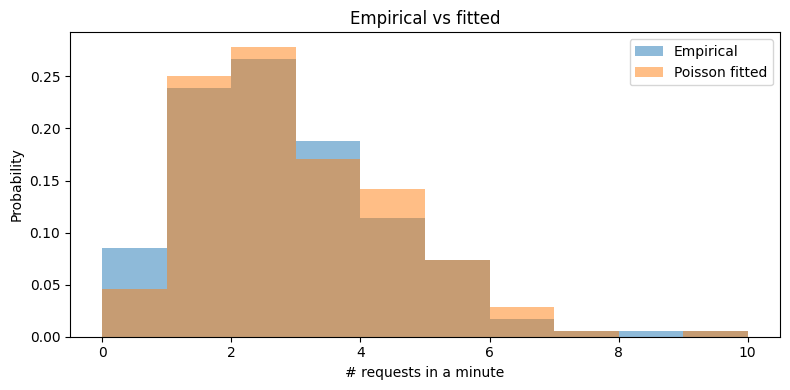

In [8]:
# 1.6 Confrontare i dati empirici con una distribuzione appropriata che descrive il processo con parametri stimati prima
sim = rng.poisson(lam=lam_hat, size=len(clean))                                                                         # lam usa 2.3977 come parametro di Poisson e size genera tanti valori quante sono le righe del dataset

# range in python non accetta float quindi modifico: bins = range(0, max(clean['requests'].max(), sim.max()) + 2)
bins = range(0, int(max(clean['requests'].max(), sim.max())) + 2)
plt.figure(figsize=(8,4))
# TO DO - Rappresenta l'istogramma dei dati empirici e dei dati simulati nello stesso grafico, con density=True per mostrare le probabilità effettive, indipendentemente dal numero di dati
plt.hist(clean['requests'], bins = bins, density=True, alpha=0.5, label='Empirical')
plt.hist(sim, bins = bins, density=True, alpha=0.5, label='Poisson fitted')
plt.title('Empirical vs fitted')
plt.xlabel('# requests in a minute')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()


## Domande

Rispondi a queste due domande *usando sia le quantità empiriche e le distribuzioni simulate*.

1) Qual è la probabilità di osservare almeno 6 accessi?
2) Qual è la probabilità di osservare esattamente 0 accessi.

In [9]:
# 1.7 Prediction / probability questions
k = 6
# TO DO - Calcola la probabilità di osservare k o più richieste in un minuto, sia empiricamente che nei dati simulati
p_emp_ge_k = (clean['requests'] >= k).mean()
p_model_ge_k = (sim >= k).mean()

p_emp_0 = (clean['requests'] == 0).mean()
p_model_0 = (sim == 0 ).mean()

print(f'P(X >= {k}) empirical: {p_emp_ge_k:.4f}')
print(f'P(X >= {k}) Model (MC): {p_model_ge_k:.4f}')
print('---')
print(f'P(X = 0) empirical: {p_emp_0:.4f}')
print(f'P(X = 0) Model (MC): {p_model_0:.4f}')


P(X >= 6) empirical: 0.0341
P(X >= 6) Model (MC): 0.0398
---
P(X = 0) empirical: 0.0852
P(X = 0) Model (MC): 0.0455


Il modello di Poisson è un buon modello per questi dati.

---

# Part 2 — Distribuzione congiunta di due variabile aleatorie

## Scenario
Per ogni cliente si registra:
- **X** = numero di shot di espresso ('shots')
- **Y** = dessert ordinato? (`dessert`, 0=no/1=si)

Le variabili sono indipendenti/non correlate?

Calcoliamo:
- la tabella corrispondente alla pmf congiunta
- le marginali
- le distribuzioni condizionali
- facciamo un test di indipendenza
- correlazione


In [10]:
# 2.1 Load café joint dataset from CSV
cafe_csv_path = 'cafe_joint_data.csv'
cafe = pd.read_csv(cafe_csv_path)

print('Loaded:', cafe_csv_path)
print('Shape:', cafe.shape)
print(cafe.head())

print('\nMissing values:')
print(cafe.isna().sum())


Loaded: cafe_joint_data.csv
Shape: (4000, 2)
   shots  dessert
0      2        0
1      1        1
2      1        1
3      1        1
4      1        0

Missing values:
shots      0
dessert    0
dtype: int64


In [11]:
# 2.2 Clean (drop incomplete rows)
cafe_clean = cafe.dropna(subset=['shots','dessert']).copy()

# In case NaNs forced float dtype
cafe_clean['shots'] = cafe_clean['shots'].astype(int)
cafe_clean['dessert'] = cafe_clean['dessert'].astype(int)

print('Rows before:', len(cafe))
print('Rows after cleaning:', len(cafe_clean))
print('Missing after cleaning:', cafe_clean.isna().sum().to_dict())


Rows before: 4000
Rows after cleaning: 4000
Missing after cleaning: {'shots': 0, 'dessert': 0}


In [12]:
# TO DO:  Calcolare la tabella di contingenza (contingency table) tra shots e dessert, e poi stimare la pmf (normalizzata)
ct_counts = pd.crosstab(cafe_clean['shots'], cafe_clean['dessert'])                                                          # Conta le occorrenza di ogni combinazione
ct_prob = ct_counts / ct_counts.values.sum()                                                                                 # Ogni cella rappresenta la probabilità congiunta p(X=x, Y=y)

print('Counts table (X rows, Y columns):')
print(ct_counts)
print('\nEstimated joint PMF p(X,Y):')
ct_prob


Counts table (X rows, Y columns):
dessert     0    1
shots             
1         500  501
2        1675  366
3         495  463

Estimated joint PMF p(X,Y):


dessert,0,1
shots,,
1,0.12500,0.12525
2,0.41875,0.09150
3,0.12375,0.11575


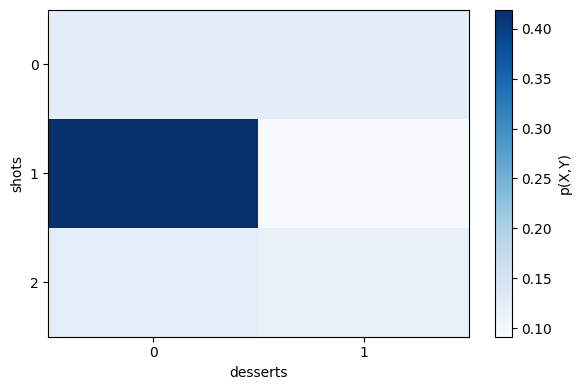

In [13]:
# TO DO: visuaizza la pmf congiunta come un'immagine (heatmap) con una colorbar appropriata e le etichette degli assi
plt.figure(figsize=(6,4))

plt.imshow(ct_prob, cmap='Blues', aspect='auto')
plt.colorbar(label='p(X,Y)')
plt.xticks(ticks=range(len(ct_prob.columns)), label=ct_prob.columns)
plt.yticks(ticks=range(len(ct_prob.index)), label=ct_prob.index)

plt.xlabel('desserts')
plt.ylabel('shots')

plt.tight_layout()
plt.show()

In [14]:
# TO DO: calcolare le marginali stimando pX e pY a partire dalla pmf congiunta
pX_hat = ct_prob.sum(axis=1) # sum over y
pY_hat = ct_prob.sum(axis=0) # sum over x

print('Estimated pX:')
print(pX_hat)
print('\nEstimated pY:')
print(pY_hat)


Estimated pX:
shots
1    0.25025
2    0.51025
3    0.23950
dtype: float64

Estimated pY:
dessert
0    0.6675
1    0.3325
dtype: float64


In [15]:
# TO DO: calcolare le distribuzioni condizionate p(Y|X) e p(X|Y) a partire dalla pmf congiunta e dalle marginali
pY_given_X = ct_prob.div(pX_hat, axis=0)  # rows: X
pX_given_Y = ct_prob.div(pY_hat, axis=1) # cols: Y

print('Estimated p(Y|X):')
print(pY_given_X)
print('\nEstimated p(X|Y):')
print(pX_given_Y)


Estimated p(Y|X):
dessert         0         1
shots                      
1        0.499500  0.500500
2        0.820676  0.179324
3        0.516701  0.483299

Estimated p(X|Y):
dessert         0         1
shots                      
1        0.187266  0.376692
2        0.627341  0.275188
3        0.185393  0.348120


In [16]:
# TO DO: Test di indipendanza: 
# calcolare il prodotto delle marginali e confrontarlo con la stima della pmf congiunta. 
# Quanto sono diversi? È coerente con il fatto che i dati sono stati generati per essere non correlati?
prod = pd.DataFrame(
    np.outer(pX_hat.values, pY_hat.values),
    index=ct_prob.index,
    columns=ct_prob.columns
)
diff = ct_prob - prod

print('Product-of-marginals table:')
print(prod)
print('\nDifference (joint - product):')
print(diff)


Product-of-marginals table:
dessert         0         1
shots                      
1        0.167042  0.083208
2        0.340592  0.169658
3        0.159866  0.079634

Difference (joint - product):
dessert         0         1
shots                      
1       -0.042042  0.042042
2        0.078158 -0.078158
3       -0.036116  0.036116


## Confronto tra distribuzione marginali e PMF osservata

La tabella è costruita in modo che la somma di ogni riga e colonna sia pari a 0.

Valori positivi o negativi indicano rispettivamente un eccesso o una carenza rispetto a quanto ci si aspetterebbe in caso di indipendenza tra le variabili.

- Valore pari a 0 indica indipendenza
- Valori diversi da 0 indicano una possibile indipendenza
- Valori vicini a +- 1 rappresentano una dipendenza forte

Nel caso di "2 shots" e "0 dessert" il valore è circa 0.078 (circa 8%), superiore al livello di significatività tipico (0.05). 
Tuttavia il valore rimane molto basso non influendo sull'indipendenza.

In [17]:
# TO DO: calcolare la covarianza e la correlazione tra shots e dessert, sia a partire dalla stima della pmf congiunta che direttamente dai dati raw (un'altra misura equivalente)
# From the joint PMF:
E_X = (pX_hat.index.values * pX_hat.values).sum()
E_Y = (pY_hat.index .values* pY_hat.values).sum()

E_XY = 0.0
for x in ct_prob.index:
    for y in ct_prob.columns:
        E_XY += x * y * ct_prob.loc[x, y]

cov_XY = E_XY - E_X*E_Y # E[XY] - E[X]E[Y]

# TO DO: calcolare la correlazione a partire dalla covarianza e dalle deviazioni standard di X e Y
corr_XY = corr_XY = cafe_clean['shots'].corr(cafe_clean['dessert'])                                 # Comando pandas

print(f'E[X] ≈ {E_X:.4f}')
print(f'E[Y] ≈ {E_Y:.4f}')
print(f'E[XY] ≈ {E_XY:.4f}')
print(f'Cov(X,Y) ≈ {cov_XY:.6f}')
print(f'Corr(X,Y) ≈ {corr_XY:.6f}')


E[X] ≈ 1.9892
E[Y] ≈ 0.3325
E[XY] ≈ 0.6555
Cov(X,Y) ≈ -0.005926
Corr(X,Y) ≈ -0.017975


## Domanda
Le variabili sono indipendenti? Giustifica la risposta.

## Risposta

Analisi Covarianza e Correlazione:
- Covarianza Cov(X,Y) è vicinissima allo 0
- Correlazione Corr(X,Y) è compresa tra -1 e +1 e misuta la forza e la direzione della relazione lineare tra due variabili: 
    - Valori vicini a 0 indicano relazione lineare debole o assente
    - Valori vicini a -1 o a +1 indicano relazione forte

In conclusione, poich+ covarianza e correlazione sono entrambe molto vicine allo 0 non si osserva una relazione lineare significatica tra le variabili; esse possono quindi ssere considerate indipendenti.